# A. Data Exploration

In [12]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

## 1. Sentinel 1 radar data and Sentinel 2 multispectral data

Source: Copernicus Browser or in Google Earth Engine

## 2. Specific Marker Wadden data

Source: [Rijkswaterstaat](https://open.rijkswaterstaat.nl/@254169/datarapportage-kima-overzicht-meetdata/)

## 3a. Airborne LiDAR data from AHN5

Source: [Actueel Hoogtebestand Nederland (Current Elevation File Netherlands)](https://www.ahn.nl/dataroom)

[GeoTiles TU Delft](https://geotiles.citg.tudelft.nl/)

<div style="color:red">
Data collection date: 2023
</div>

![Screenshot of data source](images/Screenshot%202025-09-11%20191855.jpg)

In [13]:
import laspy

laz_files = [
    "data/AHN5/2023_C_20BZ1.LAZ",
    "data/AHN5/2023_C_20BZ2.LAZ",
    "data/AHN5/2023_C_20DN1.LAZ",
    "data/AHN5/2023_C_20DN2.LAZ"
]

def sample_laz(filepath, num_to_sample=None, chunk_size=1_000_000, random_state=None):
    """
    Sample up to `num_to_sample` points from a LAZ/LAS file without loading the entire file.
    Returns (x, y, z) numpy arrays of sampled coordinates.

    If num_to_sample is None, uses global `num_points` if defined, otherwise 100_000.
    """
    if num_to_sample is None:
        num_to_sample = globals().get("num_points", 100_000)

    with laspy.open(filepath) as f:
        total_points = int(f.header.point_count)
        if total_points == 0:
            raise RuntimeError(f"No points in file: {filepath}")

        num_to_sample = min(int(num_to_sample), total_points)

        rng = np.random.default_rng(random_state)
        sample_idx = rng.choice(total_points, size=num_to_sample, replace=False)
        sample_idx.sort()

        xs_chunks = []
        ys_chunks = []
        zs_chunks = []

        offset = 0
        collected = 0

        for chunk in f.chunk_iterator(chunk_size):
            chunk_len = len(chunk.x)
            if chunk_len == 0:
                offset += chunk_len
                continue

            mask = (sample_idx >= offset) & (sample_idx < offset + chunk_len)
            if mask.any():
                local_idx = sample_idx[mask] - offset
                xs_chunks.append(chunk.x[local_idx])
                ys_chunks.append(chunk.y[local_idx])
                zs_chunks.append(chunk.z[local_idx])
                collected += local_idx.size

                if collected >= num_to_sample:
                    break

            offset += chunk_len

        if collected == 0:
            raise RuntimeError("No sample points were collected; check file and sampling logic.")

        x = np.concatenate(xs_chunks)
        y = np.concatenate(ys_chunks)
        z = np.concatenate(zs_chunks)

    return x, y, z

# Sample points from all LAZ files
num_points = 200_000  # Total number of points to sample across all files
points_per_file = num_points // len(laz_files)
x_list, y_list, z_list = [], [], []
for laz_file in laz_files:
    x_chunk, y_chunk, z_chunk = sample_laz(laz_file, num_to_sample=points_per_file, random_state=42)
    x_list.append(x_chunk)
    y_list.append(y_chunk)
    z_list.append(z_chunk)
x = np.concatenate(x_list)
y = np.concatenate(y_list)
z = np.concatenate(z_list)
# Print some basic information
print(f"Sampled {len(x)} points from {len(laz_files)} LAZ files.")
print(f"X range: {x.min()} - {x.max()}")
print(f"Y range: {y.min()} - {y.max()}")
print(f"Z range: {z.min()} - {z.max()}")


Sampled 200000 points from 4 LAZ files.
X range: 151523.747 - 159999.94
Y range: 506250.017 - 518749.876
Z range: -5.498 - 23.135


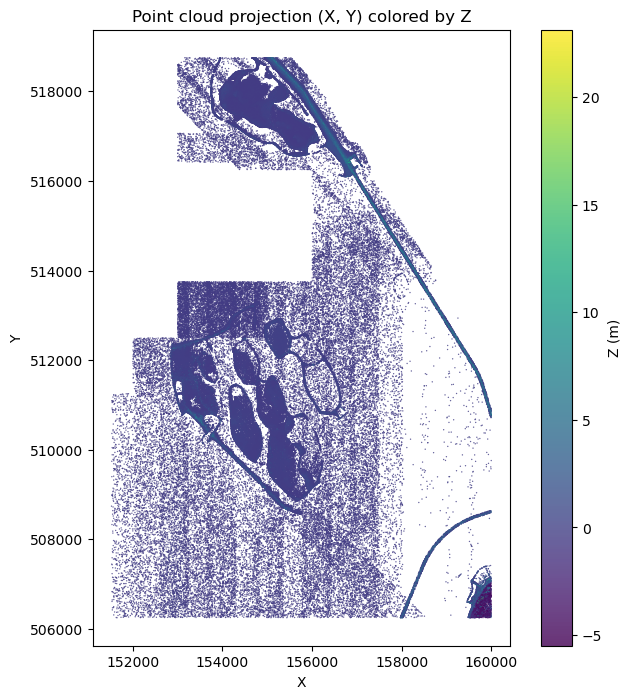

In [14]:
# 2D scatter of point cloud (X, Y) with Z shown as color
# Uses existing sampled arrays: x, y, z

fig2, ax2 = plt.subplots(figsize=(10, 8))
sc = ax2.scatter(x, y, c=z, s=1, cmap='viridis', alpha=0.8, linewidths=0)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('Point cloud projection (X, Y) colored by Z')
ax2.set_aspect('equal', adjustable='box')
cbar = fig2.colorbar(sc, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('Z (m)')
plt.show()

In [15]:
# Crop data to a region of interest (optional)
# Define bounding box (min_x, max_x, min_y, max_y)
min_x, max_x = 152000, 157000
min_y, max_y = 508000, 514000
bbox = (min_x, max_x, min_y, max_y)
# Filter points within bounding box
mask = (x >= min_x) & (x <= max_x) & (y >= min_y) & (y <= max_y)
x = x[mask]
y = y[mask]
z = z[mask]
# Print some basic information
print(f"Filtered to {len(x)} points within bounding box {bbox}.")

Filtered to 96258 points within bounding box (152000, 157000, 508000, 514000).


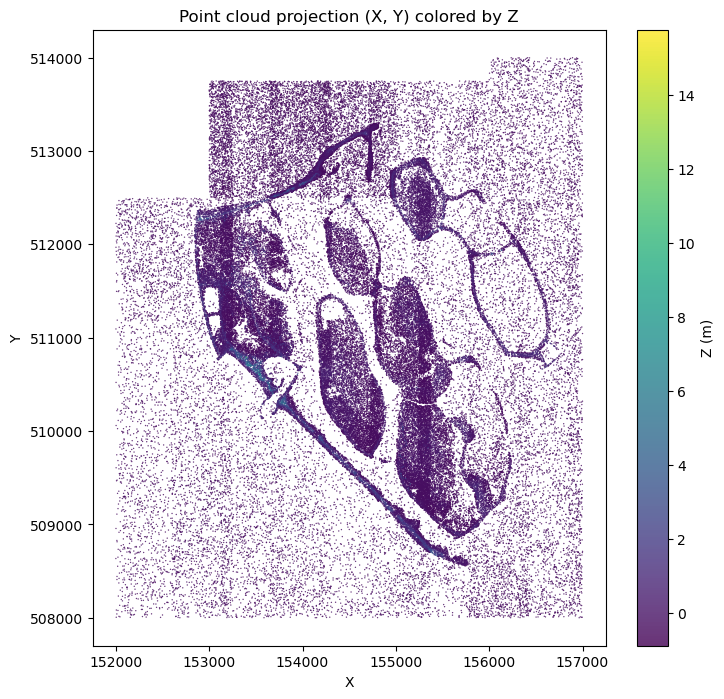

In [16]:
# 2D scatter of point cloud (X, Y) with Z shown as color
# Uses existing sampled arrays: x, y, z

fig2, ax2 = plt.subplots(figsize=(10, 8))
sc = ax2.scatter(x, y, c=z, s=1, cmap='viridis', alpha=0.8, linewidths=0)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('Point cloud projection (X, Y) colored by Z')
ax2.set_aspect('equal', adjustable='box')
cbar = fig2.colorbar(sc, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('Z (m)')
plt.show()

## 3b. Aerial photos from BN


Source: [Beeldmateriaal Nederland (Image material Netherlands)](https://www.beeldmateriaal.nl/)

[GeoTiles TU Delft](https://geotiles.citg.tudelft.nl/)

<div style="color:red">
Data collection date: Spring flight 2025
</div>

![GeoJSON data preview showing polygon footprints and metadata for aerial imagery tiles](images/Screenshot%202025-09-13%20091626.jpg)

Referenced image files:
['https://fsn1.your-objectstorage.com/hwh-ortho/2025/Ortho/1/8/beelden_RGB_jpeg_tegels/2025_152000_511000_RGB_JPEG_hrl.tif', 'https://fsn1.your-objectstorage.com/hwh-ortho/2025/Ortho/1/8/beelden_RGB_jpeg_tegels/2025_154000_511000_RGB_JPEG_hrl.tif.aux.xml', 'https://fsn1.your-objectstorage.com/hwh-ortho/2025/Ortho/1/8/beelden_RGB_jpeg_tegels/2025_152000_511000_RGB_JPEG_hrl.tif.aux.xml', 'https://fsn1.your-objectstorage.com/hwh-ortho/2025/Ortho/1/8/beelden_RGB_jpeg_tegels/2025_154000_511000_RGB_JPEG_hrl.tif', 'https://fsn1.your-objectstorage.com/hwh-ortho/2025/Ortho/1/8/beelden_RGB_jpeg_tegels/2025_153000_511000_RGB_JPEG_hrl.tif', 'https://fsn1.your-objectstorage.com/hwh-ortho/2025/Ortho/1/8/beelden_RGB_jpeg_tegels/2025_152000_512000_RGB_JPEG_hrl.tif', 'https://fsn1.your-objectstorage.com/hwh-ortho/2025/Ortho/1/8/beelden_RGB_jpeg_tegels/2025_154000_512000_RGB_JPEG_hrl.tif', 'https://fsn1.your-objectstorage.com/hwh-ortho/2025/Ortho/1/8/beelden_RGB_jpeg_tegels/2025_

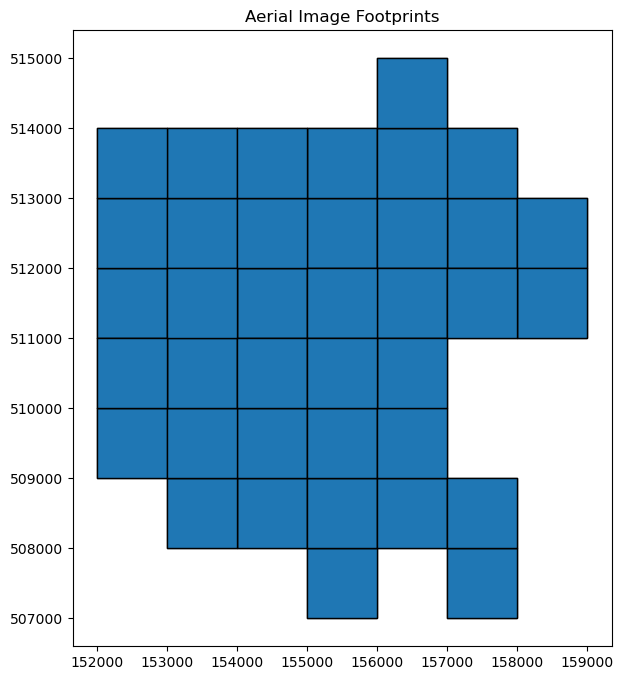

In [8]:
import geopandas as gpd
from pathlib import Path

geojson_path = "data/BN Imagerial Data/selectie_b2308cf8-260e-4c03-9402-2988cde1071e.geojson"
gdf = gpd.read_file(geojson_path)

# Plot footprints
ax = gdf.plot(edgecolor="black", figsize=(10, 8))
ax.set_title("Aerial Image Footprints")
ax.set_aspect("equal")

# List referenced image files from the GeoJSON properties
if "file" in gdf.columns:
    print("Referenced image files:")
    print(gdf["file"].dropna().tolist())
else:
    print("No 'file' column found in GeoJSON properties.")

In [9]:
gdf.head()

,file,size,mtime,sha256,geometry
0,https://fsn1.your-objectstorage.com/hwh-ortho/...,31329543,2025-07-16 08:03:05.442000+00:00,34baf6fc00186d7a52e4a3a639e9443127aa7740cbb8b2...,"POLYGON ((153000 511000, 153000 512000, 152000..."
1,https://fsn1.your-objectstorage.com/hwh-ortho/...,592,2025-07-16 08:04:56.202000+00:00,a915577c6150da244ab9c1714bf3f50f1d2f852a3631d1...,"POLYGON ((155000 511000, 155000 512000, 154000..."
2,https://fsn1.your-objectstorage.com/hwh-ortho/...,592,2025-07-16 08:02:57.676000+00:00,a915577c6150da244ab9c1714bf3f50f1d2f852a3631d1...,"POLYGON ((153000 511000, 153000 512000, 152000..."
3,https://fsn1.your-objectstorage.com/hwh-ortho/...,31391908,2025-07-16 08:05:08.142000+00:00,55ad73aa1cb3fe7ebc661de8bb5c53887b232c77ea4143...,"POLYGON ((155000 511000, 155000 512000, 154000..."
4,https://fsn1.your-objectstorage.com/hwh-ortho/...,37684912,2025-07-16 08:03:59.216000+00:00,86009ed85ead9c11fb28ab4d7a7f09a303f79f610b54f8...,"POLYGON ((154000 511000, 154000 512000, 153000..."


c:\Users\Move\anaconda3\envs\gds24\lib\site-packages\PIL\Image.py:3368: DecompressionBombWarning: Image size (156250000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


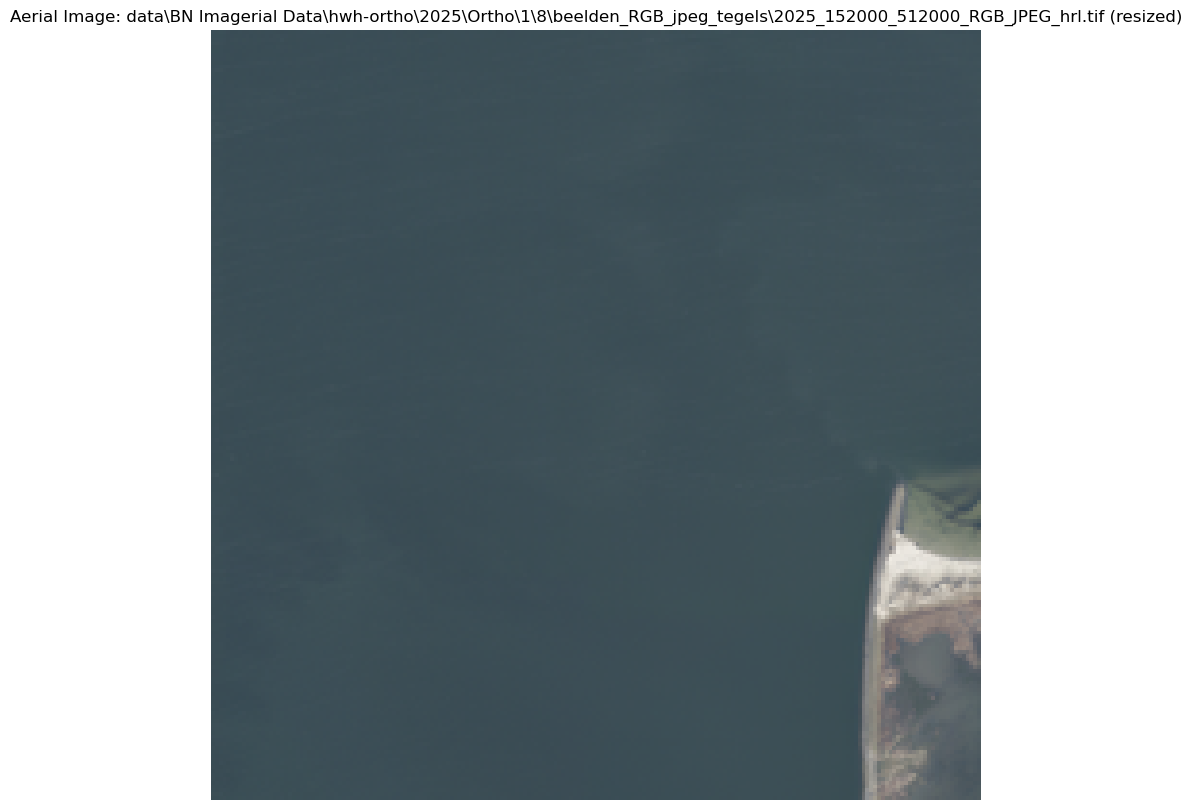

In [10]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

image_filename = Path(gdf["file"].dropna().iloc[5]).name
local_folder = Path("data/BN Imagerial Data/hwh-ortho/2025/Ortho/1/8/beelden_RGB_jpeg_tegels")
local_image_path = local_folder / image_filename

try:
    img = Image.open(local_image_path)
    # Reduce resolution (resize to max 2000x2000, keeping aspect ratio)
    max_size = (200, 200)
    img.thumbnail(max_size, Image.LANCZOS)
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.title(f"Aerial Image: {local_image_path} (resized)")
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Error loading image {local_image_path}: {e}")

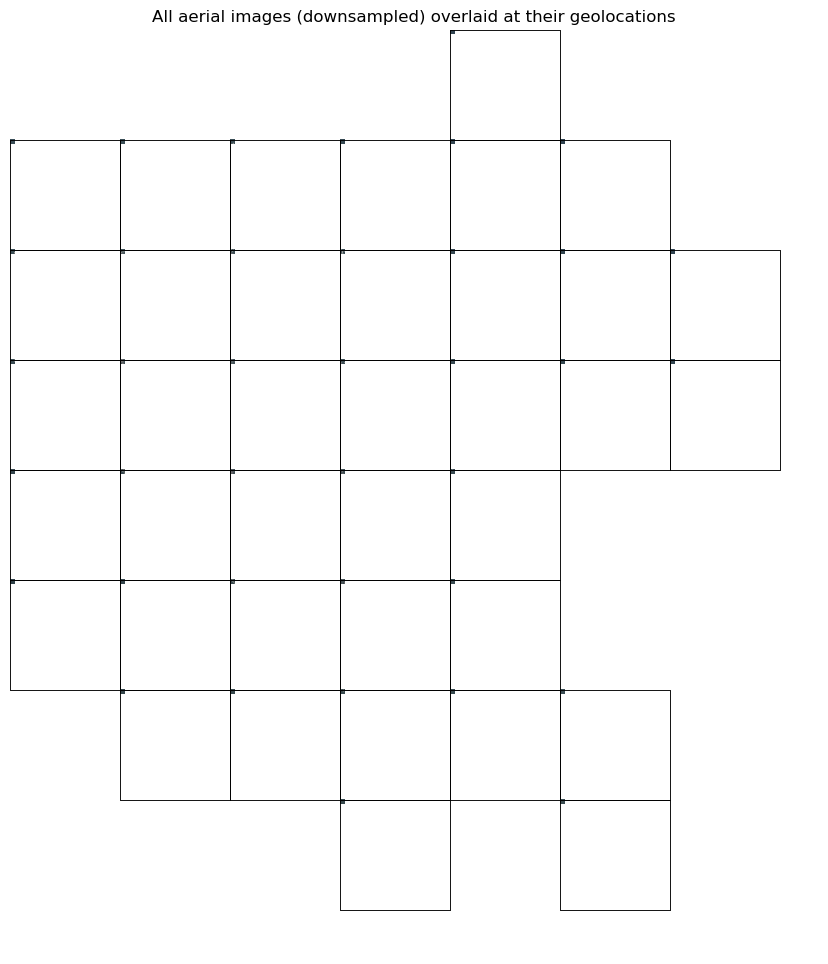

In [8]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots(figsize=(12, 12))
local_folder = Path("data/BN Imagerial Data/hwh-ortho/2025/Ortho/1/8/beelden_RGB_jpeg_tegels")

for idx, row in gdf.iterrows():
    image_filename = Path(str(row["file"])).name
    if not image_filename.lower().endswith((".tif", ".tiff")):
        continue
    local_image_path = local_folder / image_filename
    try:
        with rasterio.open(local_image_path) as src:
            # Try to use overview, else manually downsample
            if src.overviews(1):
                ovr = src.overviews(1)[-1]
                img = src.read(
                    out_shape=(
                        src.count,
                        int(src.height // ovr),
                        int(src.width // ovr)
                    ),
                    resampling=rasterio.enums.Resampling.nearest
                )
            else:
                # Downsample entire image to max 500x500 pixels
                scale = max(src.width / 500, src.height / 500, 1)
                img = src.read(
                    out_shape=(
                        src.count,
                        int(src.height // scale),
                        int(src.width // scale)
                    ),
                    resampling=rasterio.enums.Resampling.nearest
                )
            show(img, transform=src.transform, ax=ax)
    except Exception as e:
        print(f"Error loading image {local_image_path}: {e}")

gdf.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5)
ax.set_title("All aerial images (downsampled) overlaid at their geolocations")
ax.set_aspect("equal")
plt.axis('off')
plt.show()

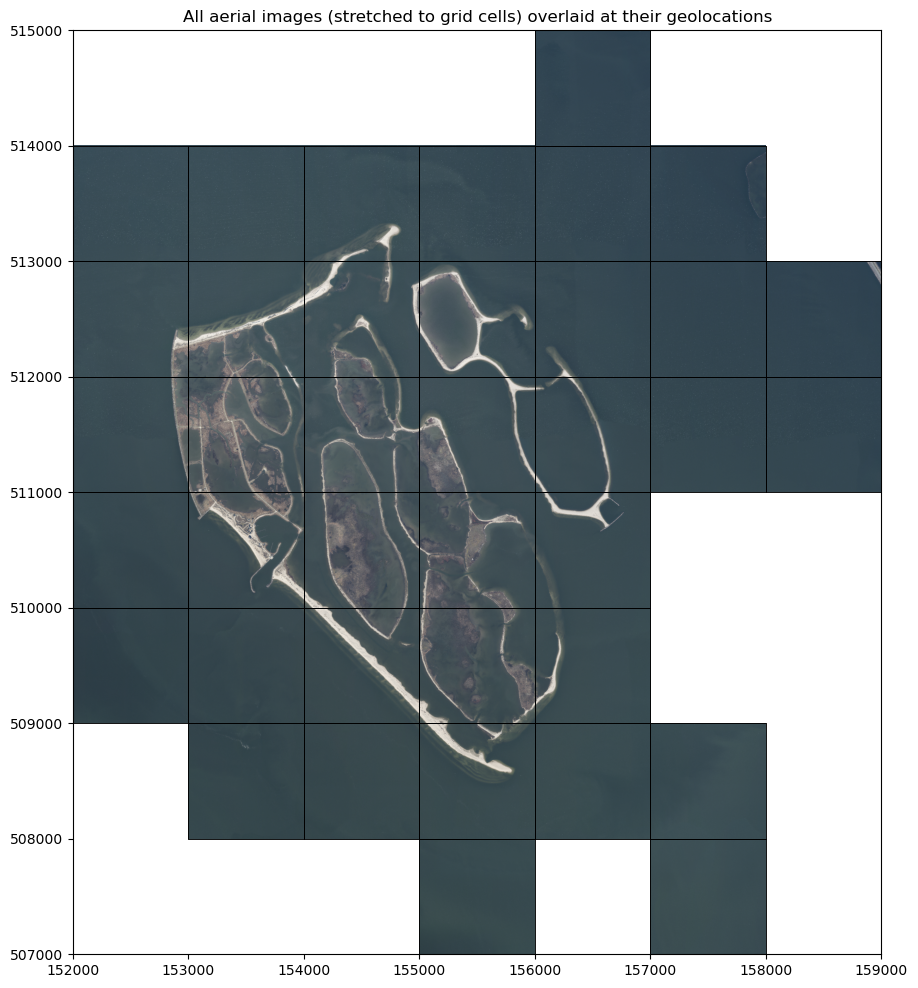

In [11]:
from rasterio.transform import from_bounds
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots(figsize=(12, 12))
max_size = 500  # target max pixels on longest side
local_folder = Path("data/BN Imagerial Data/hwh-ortho/2025/Ortho/1/8/beelden_RGB_jpeg_tegels")

for idx, row in gdf.iterrows():
    image_filename = Path(str(row["file"])).name
    if not image_filename.lower().endswith((".tif", ".tiff")):
        continue
    local_image_path = local_folder / image_filename
    try:
        with rasterio.open(local_image_path) as src:
            # choose overview or compute scale
            if src.overviews(1):
                ovr = src.overviews(1)[-1]
                out_height = max(1, int(src.height // ovr))
                out_width = max(1, int(src.width // ovr))
            else:
                scale = max(src.width / max_size, src.height / max_size, 1.0)
                out_width = max(1, int(src.width / scale))
                out_height = max(1, int(src.height / scale))

            img = src.read(
                out_shape=(src.count, out_height, out_width),
                resampling=rasterio.enums.Resampling.nearest
            )

            # Stretch the downsampled image to exactly fill the geometry bounds
            minx, miny, maxx, maxy = row["geometry"].bounds
            new_transform = from_bounds(minx, miny, maxx, maxy, out_width, out_height)

            show(img, transform=new_transform, ax=ax, title=image_filename)
    except Exception as e:
        print(f"Error loading image {local_image_path}: {e}")

gdf.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5)
ax.set_title("All aerial images (stretched to grid cells) overlaid at their geolocations")
ax.set_aspect("equal")
plt.axis('on')
plt.show()

## 4. High resolution satellite imagery

Source: [Netherlands Space Office (NSO) Satellite Data Portal](https://www.satellietdataportaal.nl/)